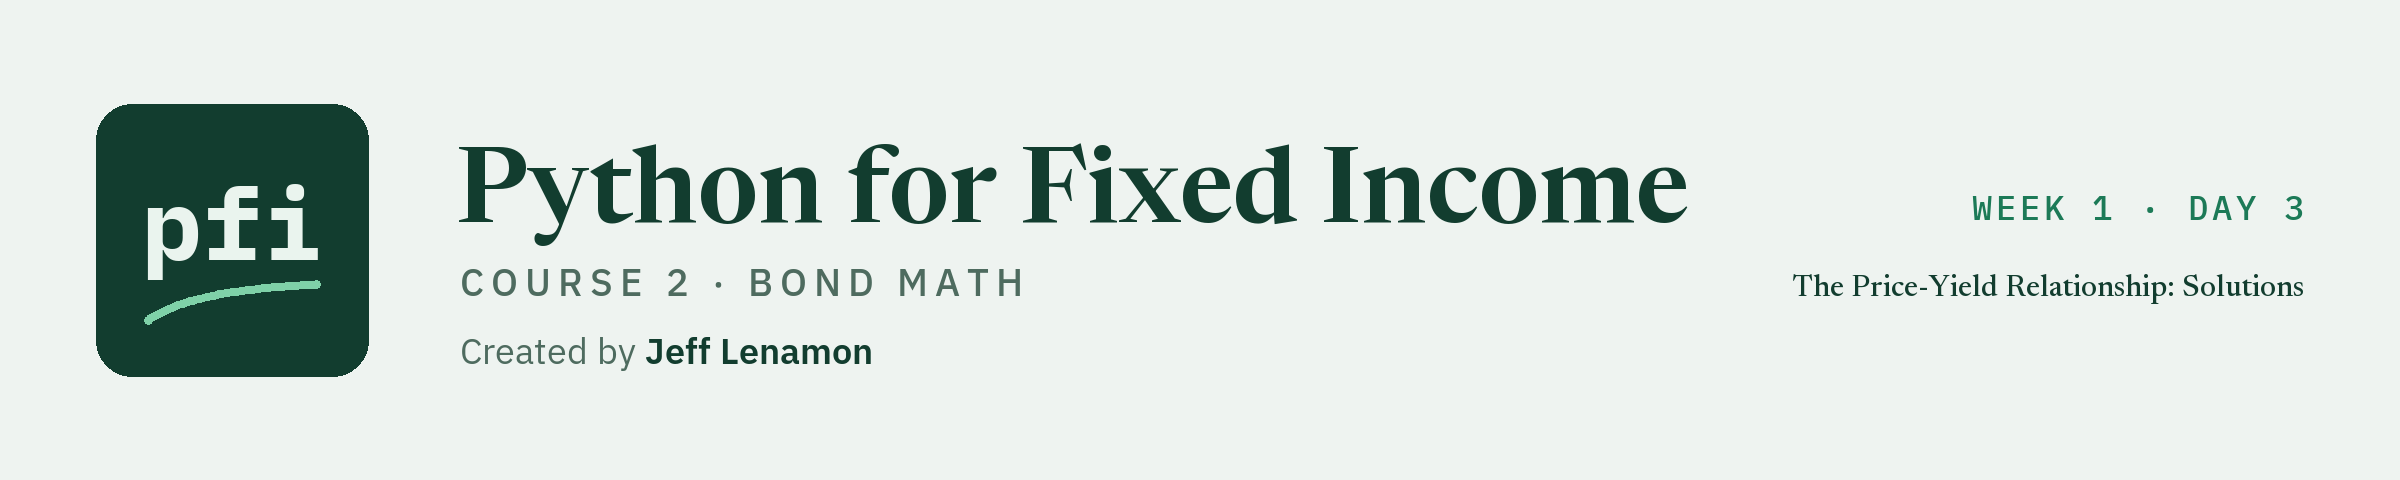

# The Price-Yield Relationship: Solutions

Week 1, Day 3. Worked answers to the exercises. Try each one yourself first.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course2_bond_math/week1/day3/03_the_price_yield_relationship_solutions.ipynb)

This notebook stands on its own. Its setup writes `bondmath.py` and `test_bondmath.py` as they stand at the end of today, so the exercises can be run without the lesson.

Q. Set up today's work folder.

In [1]:
# modules that come with Python: folders and files, the temp folder, running programs, reloading a module
import importlib
import os
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

import pandas as pd

# pytest runs the tests. A Colab runtime may not have it.
try:
    import pytest
except ImportError:
    raise RuntimeError("pytest is not installed. Run  !pip install pytest  in a new cell, then run this cell again.") from None

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "bondmath_excel_reference.csv").exists()
data_folder = RAW_DATA if on_github else str(local_data) + os.sep

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course2_03_"))
os.chdir(work)

# 3. copy the two Excel reference files into the work folder
for name in ["bondmath_excel_reference.csv", "bondmath_excel_reference_tvm.csv"]:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Reference files copied from: {'GitHub' if on_github else 'the data folder of the course repo'}")
print(f"pytest version: {pytest.__version__}")

Work folder: pfi_course2_03_4brjege6, in your temp folder
Reference files copied from: the data folder of the course repo
pytest version: 9.1.1


Q. Write `bondmath.py` and `test_bondmath.py` as they stand at the end of today.

In [2]:
%%writefile bondmath.py
"""bondmath: bond math for fixed-rate bullet bonds, checked against Excel.

Written day by day in Python for Fixed Income, Course 2: Bond Math.

Units, the same in every function:
- coupon_pct and yield_pct are annual rates in percent: 7.0 means 7 percent. Excel takes decimals (0.07).
- Prices and accrued interest are per 100 of face.
- Durations are in years, convexity in years squared, spreads in basis points.
- frequency is the number of coupons (or compounding periods) a year: 1, 2, or 4.
- basis is the day count: "30/360" (Excel basis 0) or "ACT/ACT" (Excel basis 1).
- Dates are datetime.date values.
"""
import calendar  # month lengths, used from week 2
from datetime import date  # calendar dates, used from week 2


def future_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Grow an amount at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount x (1 + rate / frequency) ** (frequency x years).
    Excel: =FV(rate_pct/100/frequency, frequency*years, 0, -amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # grow the amount over every period
    return amount * (1 + period_rate) ** periods


def present_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Discount an amount due in `years` at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount / (1 + rate / frequency) ** (frequency x years).
    Returns a positive number for a positive amount. Excel's PV returns the same number with a
    minus sign: =-PV(rate_pct/100/frequency, frequency*years, 0, amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # discount the amount over every period
    return amount / (1 + period_rate) ** periods


def cash_flows(coupon_pct: float, years: float, frequency: int = 2) -> list[tuple[float, float]]:
    """The cash flows of a bullet bond bought on a coupon date.

    Units: coupon_pct in percent of face a year, years in years. Each cash flow is per 100 of face.
    Convention: one coupon of coupon_pct / frequency every 1 / frequency years, and 100 back with
    the last coupon. Returns a list of (time in years, cash flow) pairs, earliest first.
    Raises ValueError unless years x frequency is a whole number of periods.
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # count the coupon periods and check they are whole
    periods = years * frequency
    if periods <= 0 or abs(periods - round(periods)) > 1e-9:
        raise ValueError(f"{years} years is not a whole number of periods at frequency {frequency}")
    periods = round(periods)
    # each coupon is the annual coupon split into equal parts
    coupon = coupon_pct / frequency
    flows = []
    for k in range(1, periods + 1):
        # the time of payment k, in years
        time_years = k / frequency
        # the last payment also returns the face of 100
        amount = coupon + 100 if k == periods else coupon
        flows.append((time_years, amount))
    return flows


def price_from_yield(coupon_pct: float, yield_pct: float, years: float, frequency: int = 2) -> float:
    """Price of a bullet bond on a coupon date, from its yield.

    Units: coupon_pct and yield_pct in percent a year, years in years, price per 100 of face.
    Convention: each cash flow is discounted at yield_pct compounded `frequency` times a year.
    On a coupon date there is no accrued interest, so this is both the clean and the dirty price.
    Excel: =-PV(yield_pct/100/frequency, frequency*years, coupon_pct/frequency, 100)
    """
    # the yield for one period, as a decimal
    period_yield = yield_pct / 100 / frequency
    price = 0.0
    for time_years, amount in cash_flows(coupon_pct, years, frequency):
        # discount each cash flow by one factor per period until it is paid
        price += amount / (1 + period_yield) ** (time_years * frequency)
    return price


def convert_yield(yield_pct: float, from_frequency: int, to_frequency: int) -> float:
    """The same yield restated at another compounding frequency.

    Units: yield_pct in percent a year; the result is in percent a year.
    Convention: both rates grow 100 to the same amount in one year.
    Excel: convert_yield(y, f, 1) is =EFFECT(y/100, f)*100, and convert_yield(y, 1, f) is =NOMINAL(y/100, f)*100.
    """
    # stop on a frequency the course does not use
    for frequency in (from_frequency, to_frequency):
        if frequency not in (1, 2, 4):
            raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # how much 1 grows to in one year at the original frequency
    growth_one_year = (1 + yield_pct / 100 / from_frequency) ** from_frequency
    # the rate per period at the new frequency that gives the same growth
    period_rate = growth_one_year ** (1 / to_frequency) - 1
    # back to an annual rate in percent
    return period_rate * to_frequency * 100

Writing bondmath.py


In [3]:
%%writefile test_bondmath.py
"""Tests for bondmath.py.

Every expected value comes from Excel: the two reference CSV files in this folder, or a small hand
table whose values those files confirm. Run from this folder with:  python -m pytest
"""
import csv
import math  # used from week 3
from datetime import date  # used from week 2
from pathlib import Path

import pytest

import bondmath

# the reference files sit in the same folder as this test file
HERE = Path(__file__).parent


def read_rows(file_name: str) -> list[dict]:
    """Read a reference CSV from this folder: one dict per row, every value a string."""
    with open(HERE / file_name, newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))


TVM = read_rows("bondmath_excel_reference_tvm.csv")


def tvm_rows(function: str) -> list[dict]:
    """The week 1 reference rows for one Excel function, for example "FV"."""
    rows = [row for row in TVM if row["function"] == function]
    assert rows, f"no {function} rows in the reference file"
    return rows


def test_future_value_matches_excel_fv():
    for row in tvm_rows("FV"):
        # the inputs, in course units
        amount, rate_pct = float(row["amount"]), float(row["rate_pct"])
        years, frequency = float(row["years"]), int(row["frequency"])
        result = bondmath.future_value(amount, rate_pct, years, frequency)
        # Excel's FV, with the amount entered as -amount, is positive
        assert result == pytest.approx(float(row["excel_value"]), abs=1e-6), row["case_id"]


def test_present_value_matches_excel_pv():
    for row in tvm_rows("PV"):
        amount, rate_pct = float(row["amount"]), float(row["rate_pct"])
        years, frequency = float(row["years"]), int(row["frequency"])
        result = bondmath.present_value(amount, rate_pct, years, frequency)
        # Excel's PV of a positive amount is negative (money paid now), so compare with minus the Excel value
        assert result == pytest.approx(-float(row["excel_value"]), abs=1e-6), row["case_id"]


def test_present_value_undoes_future_value():
    for frequency in (1, 2, 4):
        # grow 100 for 3 years at 5 percent, then discount it back
        grown = bondmath.future_value(100, 5.0, 3, frequency)
        assert bondmath.present_value(grown, 5.0, 3, frequency) == pytest.approx(100, abs=1e-9)


REFERENCE = read_rows("bondmath_excel_reference.csv")


def test_cash_flows_count_and_final_flow():
    flows = bondmath.cash_flows(6.0, 5, 2)
    # 5 years of half-year coupons is 10 cash flows
    assert len(flows) == 10
    # the first is a 3.00 coupon after half a year, the last is the coupon plus the face at 5 years
    assert flows[0] == pytest.approx((0.5, 3.0))
    assert flows[-1] == pytest.approx((5.0, 103.0))


def test_cash_flows_raises_on_part_periods():
    # 2.3 years is not a whole number of half years, so cash_flows must stop with a ValueError
    try:
        bondmath.cash_flows(6.0, 2.3, 2)
    except ValueError:
        return
    assert False, "cash_flows accepted 2.3 years at frequency 2"


def test_price_from_yield_matches_excel():
    # Excel's -PV with a coupon: a bond priced on a coupon date
    for row in tvm_rows("PV_BOND"):
        result = bondmath.price_from_yield(float(row["coupon_pct"]), float(row["rate_pct"]),
                                           float(row["years"]), int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]), abs=1e-6), row["case_id"]
    # Excel's PRICE on the rows that settle on a coupon date (no days accrued)
    coupon_date_rows = [row for row in REFERENCE if row["coupdaybs"] == "0"]
    assert coupon_date_rows, "no coupon-date rows in the reference file"
    for row in coupon_date_rows:
        frequency = int(row["frequency"])
        years = int(row["coupnum"]) / frequency
        result = bondmath.price_from_yield(float(row["coupon_pct"]), float(row["yield_pct"]), years, frequency)
        assert result == pytest.approx(float(row["price"]), abs=1e-6), row["case_id"]


def test_convert_yield_matches_excel_effect_and_nominal():
    # EFFECT restates a rate compounded `frequency` times a year as an annually compounded rate
    for row in tvm_rows("EFFECT"):
        result = bondmath.convert_yield(float(row["rate_pct"]), int(row["frequency"]), 1)
        # Excel returns a decimal, bondmath a percent
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-9), row["case_id"]
    # NOMINAL goes the other way: from annual compounding to `frequency` times a year
    for row in tvm_rows("NOMINAL"):
        result = bondmath.convert_yield(float(row["rate_pct"]), 1, int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-9), row["case_id"]


def test_convert_yield_round_trip():
    # semiannual to quarterly and back gives the yield we started with
    quarterly = bondmath.convert_yield(6.0, 2, 4)
    assert bondmath.convert_yield(quarterly, 4, 2) == pytest.approx(6.0, abs=1e-12)

Writing test_bondmath.py


Q. Import the module.

In [4]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import bondmath

# reload reads the file again, so that running this cell after a change picks up the change
importlib.reload(bondmath)

# the functions defined in the module itself, not the ones it imports
functions = [name for name, obj in vars(bondmath).items() if callable(obj) and getattr(obj, "__module__", "") == "bondmath"]
print(f"bondmath functions: {functions}")

bondmath functions: ['future_value', 'present_value', 'cash_flows', 'price_from_yield', 'convert_yield']


## Exercises

The exercises use the second set of four bonds from days 1 and 2, bought on 30 September 2026 like the first four. The issuers are invented, every answer describes the data, and every yield move is a what-if.

Replace each `...` with your own code, then run the check cell. Print the numbers you rely on with f-strings. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It types in the second set of bonds and defines `check`, a small function that marks your answers.

In [5]:
exercise_bonds = pd.DataFrame({
    "cusip": ['99005FZA4', '99007HZA8', '99008IZA5', '99009JZA2'],
    "issuer": ['Ostrevale Telecom', 'Tarnwick Utilities', 'Osmere Chemicals', 'Calderby Retail'],
    "ticker": ['OSTV', 'TRNW', 'OSMC', 'CLDB'],
    "rating": ['BBB-', 'A', 'BBB-', 'B'],
    "coupon_pct": [5.625, 4.375, 5.0, 8.25],
    "maturity": ['2030-09-30', '2028-09-30', '2032-09-30', '2034-09-30'],
    "years": [4, 2, 6, 8],
    "yield_pct": [5.8, 4.3, 5.35, 8.6],
})


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")


exercise_bonds

,cusip,issuer,ticker,rating,coupon_pct,maturity,years,yield_pct
0,99005FZA4,Ostrevale Telecom,OSTV,BBB-,5.625,2030-09-30,4,5.80
1,99007HZA8,Tarnwick Utilities,TRNW,A,4.375,2028-09-30,2,4.30
2,99008IZA5,Osmere Chemicals,OSMC,BBB-,5.000,2032-09-30,6,5.35
3,99009JZA2,Calderby Retail,CLDB,B,8.250,2034-09-30,8,8.60


### Exercise 1

Q. Pull to par. Hold each bond's yield where it is, and price it today and on the coupon date when it has 1 year left. Store Calderby's price with 1 year left, unrounded, in **ex1_calderby_1y**, and a list of the tickers whose price falls toward 100 as maturity comes closer in **ex1_falling**.

In [6]:
exercise_bonds["price_today"] = [
    bondmath.price_from_yield(c, y, t)
    for c, y, t in zip(exercise_bonds["coupon_pct"], exercise_bonds["yield_pct"], exercise_bonds["years"])
]
# the same yield, with 1 year left to run
exercise_bonds["price_1y_left"] = [
    bondmath.price_from_yield(c, y, 1) for c, y in zip(exercise_bonds["coupon_pct"], exercise_bonds["yield_pct"])
]
print(exercise_bonds[["ticker", "coupon_pct", "yield_pct", "years", "price_today", "price_1y_left"]].round(4))

ex1_calderby_1y = exercise_bonds.loc[exercise_bonds["ticker"] == "CLDB", "price_1y_left"].iloc[0]
# a premium bond's price falls toward 100
ex1_falling = exercise_bonds.loc[exercise_bonds["price_today"] > 100, "ticker"].tolist()

print(f"Calderby with 1 year left: {ex1_calderby_1y:.4f}. Falling toward 100: {ex1_falling}")

  ticker  coupon_pct  yield_pct  years  price_today  price_1y_left
0   OSTV       5.625       5.80      4      99.3832        99.8323
1   TRNW       4.375       4.30      2     100.1423       100.0726
2   OSMC       5.000       5.35      6      98.2238        99.6636
3   CLDB       8.250       8.60      8      98.0052        99.6713
Calderby with 1 year left: 99.6713. Falling toward 100: ['TRNW']


* Calderby rises from 98.0052 today to 99.6713 with 1 year left: a discount bond pulled up toward 100.
* Only Tarnwick falls, from 100.1423 to 100.0726: its coupon, 4.375 percent, is the only one above its yield, so it is the only premium bond.

In [7]:
check("Exercise 1 Calderby with 1 year left", ex1_calderby_1y, 99.67134685052798)
check("Exercise 1 falling toward 100", ex1_falling, ["TRNW"])

Exercise 1 Calderby with 1 year left: correct
Exercise 1 falling toward 100: correct


### Exercise 2

Q. Move Osmere's yield 100 basis points down and 100 basis points up. Store the two price changes in points, unrounded, in **ex2_down_points** (the yield 100 basis points lower) and **ex2_up_points** (100 higher), and in **ex2_larger** the word `"down"` or `"up"`: the move whose price change is larger in size.

In [8]:
osmere = exercise_bonds[exercise_bonds["ticker"] == "OSMC"].iloc[0]
today = bondmath.price_from_yield(osmere["coupon_pct"], osmere["yield_pct"], osmere["years"])

# 100 basis points is 1 percentage point of yield
ex2_down_points = bondmath.price_from_yield(osmere["coupon_pct"], osmere["yield_pct"] - 1, osmere["years"]) - today
ex2_up_points = bondmath.price_from_yield(osmere["coupon_pct"], osmere["yield_pct"] + 1, osmere["years"]) - today
ex2_larger = "down" if abs(ex2_down_points) > abs(ex2_up_points) else "up"

print(f"Osmere at {today:.4f}: yield 100 bp lower {ex2_down_points:+.4f} points, 100 bp higher {ex2_up_points:+.4f} points")
print(f"Larger move: {ex2_larger}")

Osmere at 98.2238: yield 100 bp lower +5.1766 points, 100 bp higher -4.8731 points
Larger move: down


* Down 100 basis points the price rises 5.1766; up 100 it falls 4.8731. The fall in yield moves the price more: the bend of the price-yield curve from section 3.2.
* Excel agrees: `=PRICE(DATE(2026,9,30),DATE(2032,9,30),5/100,4.35/100,100,2,0)` returns 103.400335 and `=PRICE(DATE(2026,9,30),DATE(2032,9,30),5/100,6.35/100,100,2,0)` returns 93.350699.

In [9]:
check("Exercise 2 yield down 100 bp", ex2_down_points, 5.176570543702951)
check("Exercise 2 yield up 100 bp", ex2_up_points, -4.873065902034114)
check("Exercise 2 larger move", ex2_larger, "down")

Exercise 2 yield down 100 bp: correct
Exercise 2 yield up 100 bp: correct
Exercise 2 larger move: correct


### Exercise 3

Q. With `bondmath.convert_yield`, restate Calderby's semiannual yield as an annual rate, and Osmere's as a quarterly rate. Store them, in percent and unrounded, in **ex3_calderby_annual** and **ex3_osmere_quarterly**.

In [10]:
# from twice a year to once a year, and from twice a year to four times a year
ex3_calderby_annual = bondmath.convert_yield(8.60, 2, 1)
ex3_osmere_quarterly = bondmath.convert_yield(5.35, 2, 4)

print(f"Calderby: 8.60 percent semiannual is {ex3_calderby_annual:.4f} percent annual")
print(f"Osmere:   5.35 percent semiannual is {ex3_osmere_quarterly:.4f} percent quarterly")

Calderby: 8.60 percent semiannual is 8.7849 percent annual
Osmere:   5.35 percent semiannual is 5.3147 percent quarterly


* Calderby's annual rate is 8.7849 percent, 0.1849 points above its quote: the highest yield of the set, so the largest gap. Excel's `=EFFECT(8.6/100,2)` returns 0.08784899999999984, the same rate as a decimal.
* Osmere's quarterly rate is 5.3147 percent, a little below 5.35: compounding more often needs a lower quoted rate.

In [11]:
check("Exercise 3 Calderby annual", ex3_calderby_annual, 8.784899999999984)
check("Exercise 3 Osmere quarterly", ex3_osmere_quarterly, 5.314692553822908)

Exercise 3 Calderby annual: correct
Exercise 3 Osmere quarterly: correct


### Exercise 4

Q. Add a function to your module. `price_change(old_price, new_price)` returns the change as a tuple of two numbers: points per 100 of face, and percent of the old price, both negative for a fall. Write the docstring first: units, convention, and the Excel formulas. Then add a test to `test_bondmath.py`, called `test_price_change_points_and_percent`, with two cases you can check by hand, and a check that every step up the yield column of Excel's `PRICE` rows for the 5.25 percent coupon (`tvm_rows("PRICE")`) gives a fall in price. Run pytest, and store the percent change of Halvering's price when its yield moves from 7.70 to 8.70 percent, from `bondmath.price_change`, in **ex4_percent**.

Write the function in the cell that starts with `%%writefile -a bondmath.py` and the test in the one that starts with `%%writefile -a test_bondmath.py`, and run each of those cells once. Then reload the module.

In [12]:
%%writefile -a bondmath.py


def price_change(old_price: float, new_price: float) -> tuple[float, float]:
    """The change from one price to another, in points and in percent.

    Units: prices per 100 of face. Returns (points, percent): points per 100 of face, and percent of the old price.
    Convention: a fall is negative. points = new_price - old_price; percent = points / old_price x 100.
    Excel: points =new-old, percent =(new-old)/old*100
    """
    # points: the plain difference, per 100 of face
    points = new_price - old_price
    # percent: the same difference as a share of where the price started
    percent = points / old_price * 100
    return points, percent

Appending to bondmath.py


In [13]:
%%writefile -a test_bondmath.py


def test_price_change_points_and_percent():
    # hand cases: 100 to 95 is 5 points and 5 percent down; 80 to 84 is 4 points and 5 percent up
    assert bondmath.price_change(100.0, 95.0) == pytest.approx((-5.0, -5.0))
    assert bondmath.price_change(80.0, 84.0) == pytest.approx((4.0, 5.0))
    # Excel's PRICE rows for the 5-year bond at 5.25 percent: each step up in yield is a fall in price
    grid = [row for row in tvm_rows("PRICE") if row["coupon_pct"] == "5.25"]
    for lower, higher in zip(grid, grid[1:]):
        points, percent = bondmath.price_change(float(lower["excel_value"]), float(higher["excel_value"]))
        assert points < 0 and percent < 0, higher["case_id"]

Appending to test_bondmath.py


In [14]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

.........                                                                [100%]
9 passed in 0.04s



In [15]:
# the file changed, so reload before calling the new function
importlib.reload(bondmath)

before = bondmath.price_from_yield(7.5, 7.70, 10)
after = bondmath.price_from_yield(7.5, 8.70, 10)
# the function returns two values: unpack them into two names
points, ex4_percent = bondmath.price_change(before, after)

print(f"Halvering, 7.70 to 8.70 percent: {points:+.4f} points, {ex4_percent:+.4f} percent")

Halvering, 7.70 to 8.70 percent: -6.5299 points, -6.6211 percent


* `9 passed`: the eight tests of the lesson and the new one.
* Halvering falls 6.5299 points, or 6.6211 percent, the same as the table in section 3.3 of the lesson.
* The function returns a tuple, and `points, ex4_percent = ...` unpacks it into two names, as `fig, ax = plt.subplots()` does.
* In Excel, with the old price in B1 and the new in B2: `=B2-B1` for points and `=(B2-B1)/B1*100` for percent.

In [16]:
check("Exercise 4 percent change", ex4_percent, -6.621129485219808)

Exercise 4 percent change: correct


### Exercise 5: AI check

You ask an AI assistant to write `convert_yield` for you, and you give it the docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
The same yield restated at another compounding frequency.

Units: yield_pct in percent a year; the result is in percent a year.
Convention: both rates grow 100 to the same amount in one year.
Excel: convert_yield(y, f, 1) is =EFFECT(y/100, f)*100, and convert_yield(y, 1, f) is =NOMINAL(y/100, f)*100.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, and it contains one bug: a convention error.

* The bug: the code used `yield_pct`, a percent, as if it were a decimal. 5.40 went in as 540 percent, so one year's growth came out as 13.6900 times the money instead of 1.054729, and Quorvane's annual rate came back as 12.6900.
* The test caught it on the first `EFFECT` row, `tvm_effect_01`: 11.250000 against Excel's 5.062500.
* The round-trip test in section 3.5 would have passed: the buggy function turns 6.0 semiannual into a quarterly number and back into 6.0, because the same mistake is made in both directions and cancels. A round trip checks that two directions undo each other, not that either is right. Only a test against Excel catches this bug.
* The fix, in the cell below: divide by 100 going in, and multiply by 100 coming out.

In [17]:
def assistant_convert_yield(yield_pct, from_frequency, to_frequency):
    """The same yield restated at another compounding frequency.

Units: yield_pct in percent a year; the result is in percent a year.
Convention: both rates grow 100 to the same amount in one year.
Excel: convert_yield(y, f, 1) is =EFFECT(y/100, f)*100, and convert_yield(y, 1, f) is =NOMINAL(y/100, f)*100.
    """
    # stop on a frequency the course does not use
    for frequency in (from_frequency, to_frequency):
        if frequency not in (1, 2, 4):
            raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the fix, part 1: yield_pct is in percent, so divide by 100 to get the decimal rate
    growth_one_year = (1 + yield_pct / 100 / from_frequency) ** from_frequency
    # the rate per period at the new frequency that gives the same growth
    period_rate = growth_one_year ** (1 / to_frequency) - 1
    # the fix, part 2: back to percent, as the docstring promises
    return period_rate * to_frequency * 100

In [18]:
# the test, written from Excel's reference rows before the code is trusted
tvm = pd.read_csv("bondmath_excel_reference_tvm.csv")
effect_rows = tvm[tvm["function"] == "EFFECT"]
nominal_rows = tvm[tvm["function"] == "NOMINAL"]

# EFFECT: from `frequency` times a year to once a year. Excel returns a decimal, so times 100.
for row in effect_rows.itertuples():
    result = assistant_convert_yield(row.rate_pct, int(row.frequency), 1)
    assert abs(result - row.excel_value * 100) < 1e-9, f"{row.case_id}: {result:.6f} against Excel's {row.excel_value * 100:.6f}"

# NOMINAL: from once a year to `frequency` times a year
for row in nominal_rows.itertuples():
    result = assistant_convert_yield(row.rate_pct, 1, int(row.frequency))
    assert abs(result - row.excel_value * 100) < 1e-9, f"{row.case_id}: {result:.6f} against Excel's {row.excel_value * 100:.6f}"

print(f"All {len(effect_rows) + len(nominal_rows)} EFFECT and NOMINAL rows match Excel")

All 22 EFFECT and NOMINAL rows match Excel


In [19]:
ex5_quorvane = assistant_convert_yield(5.40, 2, 1)
ex5_rows = len(effect_rows) + len(nominal_rows)

print(f"Quorvane annual from the fixed function: {ex5_quorvane:.4f}")
print(f"EFFECT and NOMINAL rows checked: {ex5_rows}")

Quorvane annual from the fixed function: 5.4729
EFFECT and NOMINAL rows checked: 22


* 5.4729, the annual rate from section 3.5, and all 22 rows match. The fixed function now does what its docstring says: percent in, percent out.

In [20]:
check("Exercise 5 Quorvane annual", ex5_quorvane, 5.472899999999981)
check("Exercise 5 rows checked", ex5_rows, 22)

Exercise 5 Quorvane annual: correct
Exercise 5 rows checked: correct


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```